In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\origami\AppData\Local\Temp\ipykernel_71264\2808763954.py:2: DtypeWarning: Columns (0: ONS_code, 1: ONS_geo, 2: Geo_level, 3: Country, 4: Region) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('12region.csv')


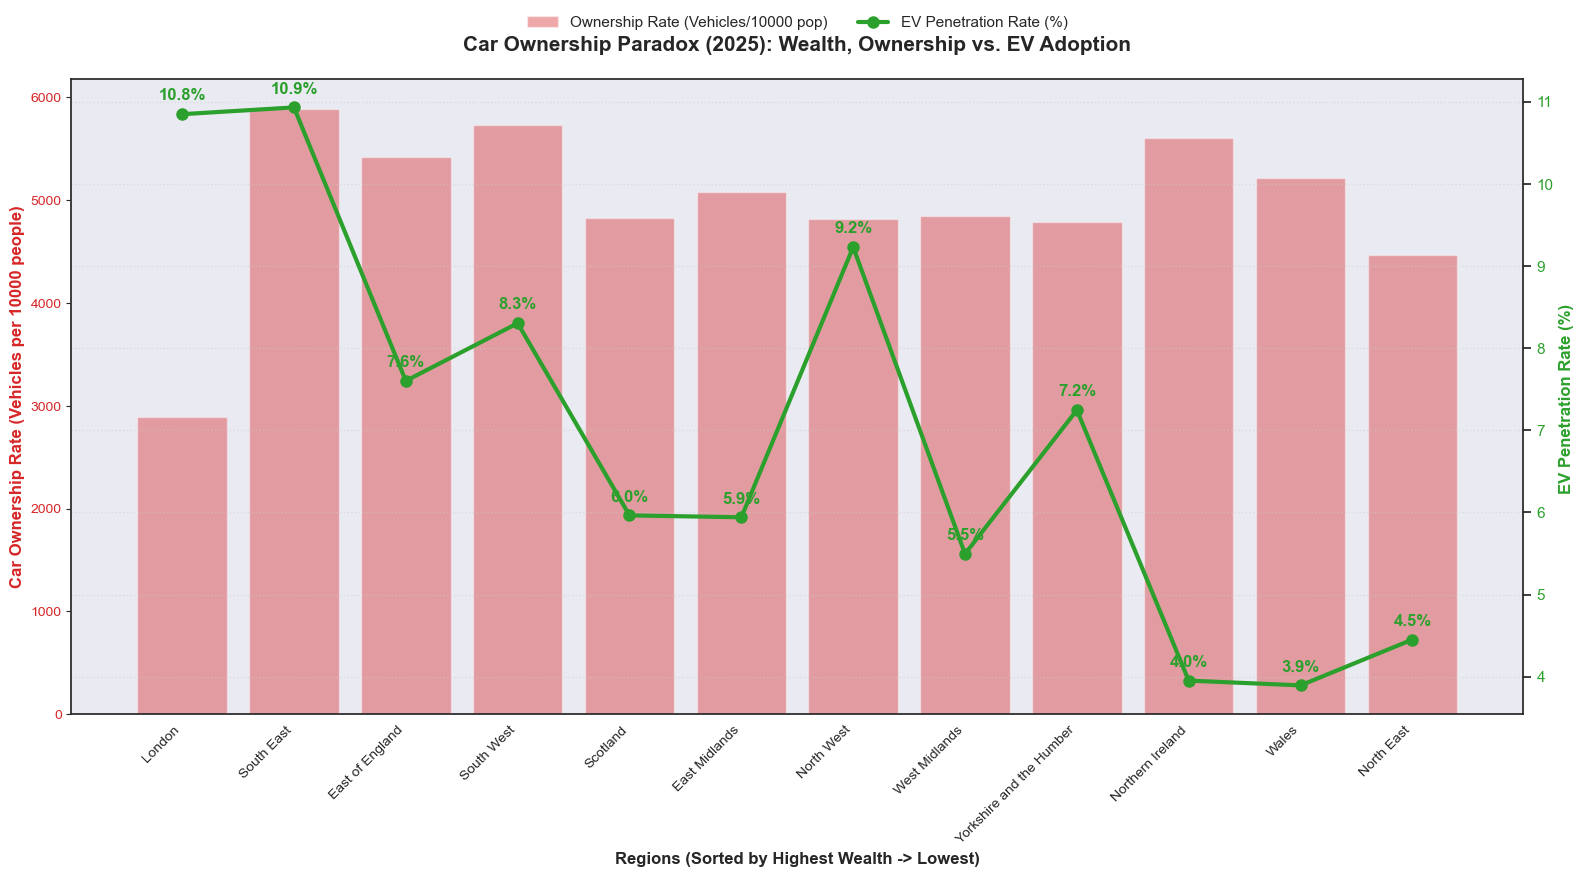


--- 2025 年拥车率悖论数据已导出至 car_ownership_paradox.csv ---
             ONS_geo  gdhi_per_head  car_ownership_rate_per_10000  \
104           London        35310.0                       2894.91   
119       South East        28183.0                       5889.90   
89   East of England        25731.0                       5419.00   
134       South West        24852.0                       5731.88   
164         Scotland        22904.0                       4826.14   

     penetration_pct  
104            10.85  
119            10.93  
89              7.60  
134             8.30  
164             5.96  


In [3]:

# 1. 加载与数据清洗
df = pd.read_csv('12region.csv')

# 确保所有需要计算的列都是数值格式
cols_to_numeric = ['veh_total', 'pop_value', 'veh_ulev_total', 'gdhi_per_head', 'year']
for col in cols_to_numeric:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 2. 提取有效年份与核心指标计算
# 提取 2023 年的 GDHI 参考表 (假设以 'ONS_code' 为匹配键)
gdhi_lookup = df[df['year'] == 2023].set_index('ONS_code')['gdhi_per_head']

# 2. 将 2023 年的值填充到 2025 年（仅针对 2025 年且 GDHI 为空的情况）
# 使用 fillna 配合 map 实现按区域精准填充
mask_2025 = df['year'] == 2025
df.loc[mask_2025, 'gdhi_per_head'] = df.loc[mask_2025, 'gdhi_per_head'].fillna(
    df.loc[mask_2025, 'ONS_code'].map(gdhi_lookup)
)

# 现在可以安全地 dropna 了，因为 2025 年已经被填上了
df_valid = df.dropna(subset=['year', 'pop_value', 'veh_total', 'veh_ulev_total', 'gdhi_per_head']).copy()

# 筛选 2025 年数据
df_paradox = df_valid[df_valid['year'] == 2025].copy()

# 核心计算
df_paradox['car_ownership_rate_per_10000'] = (df_paradox['veh_total'] / df_paradox['pop_value']) * 10000
df_paradox['penetration_pct'] = (df_paradox['veh_ulev_total'] / df_paradox['veh_total']) * 100

# 排序（此时 2025 年的 gdhi_per_head 已不再是空值）
df_paradox = df_paradox.sort_values(by='gdhi_per_head', ascending=False)


# 3. 绘制双轴组合图 (柱状图 + 折线图)
# 设置图形大小和风格
fig, ax1 = plt.subplots(figsize=(16, 9))
sns.set_theme(style="white")

# --- 左侧 Y 轴：柱状图 (千人拥车率) ---
color1 = '#d62728' # 红色系
ax1.set_xlabel('Regions (Sorted by Highest Wealth -> Lowest)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Car Ownership Rate (Vehicles per 10000 people)', color=color1, fontsize=12, fontweight='bold')

# 绘制柱子，并设置半透明以免喧宾夺主
bars = ax1.bar(df_paradox['ONS_geo'], df_paradox['car_ownership_rate_per_10000'], 
               color=color1, alpha=0.4, label='Ownership Rate (Vehicles/10000 pop)')
ax1.tick_params(axis='y', labelcolor=color1)

# X轴标签倾斜，防止文字重叠
ax1.set_xticks(range(len(df_paradox['ONS_geo'])))
ax1.set_xticklabels(df_paradox['ONS_geo'], rotation=45, ha='right')
ax1.grid(False) # 关闭柱状图背景网格使画面干净

# --- 右侧 Y 轴：折线图 (新能源渗透率) ---
ax2 = ax1.twinx()  
color2 = '#2ca02c' # 绿色系
ax2.set_ylabel('EV Penetration Rate (%) ', color=color2, fontsize=12, fontweight='bold')

# 绘制带有圆点标记的粗折线
line = ax2.plot(range(len(df_paradox['ONS_geo'])), df_paradox['penetration_pct'], 
                color=color2, marker='o', linewidth=3, markersize=8, label='EV Penetration Rate (%)')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.grid(True, linestyle=':', alpha=0.5)

# 为折线上的每个点添加具体的百分比数字标签
for i, txt in enumerate(df_paradox['penetration_pct'].round(1)):
    ax2.annotate(f"{txt}%", 
                 (i, df_paradox['penetration_pct'].iloc[i]), 
                 textcoords="offset points", 
                 xytext=(0,10), 
                 ha='center', color=color2, fontweight='bold')

# 4. 图表美化与数据导出
plt.title(f'Car Ownership Paradox ({int(2025)}): Wealth, Ownership vs. EV Adoption', 
          fontsize=15, fontweight='bold', pad=20)

# 合并左右两轴的图例放在顶部
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=2, frameon=False)

# 自动调整布局防裁切
fig.tight_layout()
plt.show()

# 将用于作图的排序后数据导出为 CSV
export_cols = ['ONS_geo', 'gdhi_per_head', 'car_ownership_rate_per_10000', 'penetration_pct']
paradox_summary = df_paradox[export_cols].round(2)

print(f"\n--- {int(2025)} 年拥车率悖论数据已导出至 car_ownership_paradox.csv ---")
print(paradox_summary.head()) # 打印排名前列（最富裕）的地区数据预览